In [11]:
import pandas as pd
import os


In [14]:
p = "P4"
main_dir = "../Data/Pilot/Clean/"+p+"/" 

#reading the CP data
data = pd.read_csv(os.path.join(main_dir,"CP.csv"))
data.head()

,Unnamed: 0,CigIndex,PuffIndex,Volume(ml),Duration(ms),AvgFlow(ml/sec),PeakFlow(ml/sec),TimeOfPeak(ms),IPI(ms),IPI + Duration,endtime rel,starttime rel,starttime abs,endtime abs
0,0,45,1,258.1,3166,83.1,102.1,2630,2286,5452.0,5452.0,2286.0,2020-02-28 17:44:02.286,2020-02-28 17:44:05.452
1,1,45,2,238.5,3844,63.0,86.4,3165,8868,12712.0,18164.0,14320.0,2020-02-28 17:44:14.320,2020-02-28 17:44:18.164
2,2,45,3,316.2,5012,64.7,87.8,4005,15213,20225.0,38389.0,33377.0,2020-02-28 17:44:33.377,2020-02-28 17:44:38.389
3,3,45,4,290.7,4295,68.5,90.2,3455,17983,22278.0,60667.0,56372.0,2020-02-28 17:44:56.372,2020-02-28 17:45:00.667
4,4,45,5,320.2,4931,65.3,91.0,3690,19872,24803.0,85470.0,80539.0,2020-02-28 17:45:20.539,2020-02-28 17:45:25.470


In [15]:
# extracting the smoking event start time and end time (i.e., the start of the first puff and the end of the last puff)
smoking_start = data.iloc[0]["starttime abs"]
smoking_end = data.iloc[-1]["endtime abs"]
smoking_start,smoking_end

('2020-02-28 17:44:02.286', '2020-02-28 17:52:18.474')

In [16]:
# creating a time series seperated by 200 ms)
smoking_ts = pd.date_range(start=smoking_start,end=smoking_end, freq='250ms')
#smoking_ts

In [17]:
# creating a data frame and assining the times series as the index.
# I am intilizing the label to be non smoking (i.e., 0)
smoking = pd.DataFrame(index=smoking_ts)
smoking["label"] = 0
#smoking

In [18]:
# I will loop through each puff and change the label smokinf (i.e. 1)
for puff_i in range(data.shape[0]):
    smoking[(smoking_ts >= data.iloc[puff_i]["starttime abs"]) 
               & (smoking_ts <= data.iloc[puff_i]["endtime abs"])]= 1

In [19]:
smoking

,label
2020-02-28 17:44:02.286,1
2020-02-28 17:44:02.536,1
2020-02-28 17:44:02.786,1
2020-02-28 17:44:03.036,1
2020-02-28 17:44:03.286,1
...,...
2020-02-28 17:52:17.286,1
2020-02-28 17:52:17.536,1
2020-02-28 17:52:17.786,1
2020-02-28 17:52:18.036,1


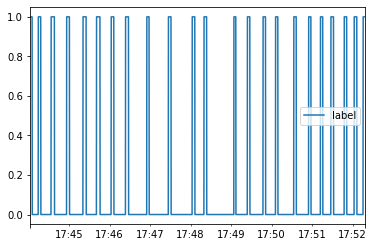

In [20]:
# plotting it just to see intial pattern
smoking.plot()

In [22]:
smoking.to_csv(os.path.join(main_dir,"CP_ts.csv"))